# Лабораторная работа №2 Винницкая Д.С.

## Импорт библиотек и настройка

In [135]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.animation import FuncAnimation
from ipywidgets import interact, FloatSlider, IntSlider, VBox, HBox, Layout, Button, Output
from IPython.display import display, clear_output
import ipywidgets as widgets

# ИМПОРТ ДЛЯ ТИПИЗАЦИИ (исправляет ошибку!)
from typing import Tuple, Optional, List

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')

# Настройка отображения графиков в notebook
%matplotlib widget
# Константы
COLLISION_ENERGY_LOSS = 0.01  # 1% потери энергии за столкновение
RESTITUTION_COEFFICIENT = np.sqrt(1 - COLLISION_ENERGY_LOSS)  # Коэффициент восстановления



## Класс шара (физическая модель)

##  Физическая модель бильярдного шара

### Параметры шара:
| Параметр | Обозначение | Единицы | Описание |
|----------|-------------|---------|----------|
| Масса | `m` | кг | Инертная характеристика |
| Радиус | `R` | м | Геометрический размер |
| Позиция | `r = (x, y)` | м | Координаты центра |
| Скорость | `v = (vx, vy)` | м/с | Вектор скорости |

### Основные формулы:

**Кинетическая энергия:**
$$E_k = \frac{1}{2}mv^2$$

**Импульс:**
$$\vec{p} = m\vec{v}$$

**Движение между столкновениями:**
$$\vec{r}(t) = \vec{r}_0 + \vec{v}t$$

>  Между столкновениями шар движется **равномерно и прямолинейно** (первый закон Ньютона)

In [136]:
class Ball:
    """
    Класс бильярдного шара
    
    Параметры:
    - position: np.array([x, y]) - координаты центра
    - velocity: np.array([vx, vy]) - вектор скорости
    - radius: float - радиус шара
    - mass: float - масса шара
    - color: str - цвет для отрисовки
    """
    
    def __init__(self, position, velocity, radius=0.1, mass=1.0, color='blue'):
        self.position = np.array(position, dtype=float)
        self.velocity = np.array(velocity, dtype=float)
        self.radius = radius
        self.mass = mass
        self.color = color
        self.initial_position = np.array(position, dtype=float)
        self.initial_velocity = np.array(velocity, dtype=float)
        
    def get_kinetic_energy(self):
        """Кинетическая энергия: E = (1/2) * m * v²"""
        v_squared = np.dot(self.velocity, self.velocity)
        return 0.5 * self.mass * v_squared
    
    def get_momentum(self):
        """Импульс: p = m * v"""
        return self.mass * self.velocity
    
    def get_speed(self):
        """Модуль скорости"""
        return np.linalg.norm(self.velocity)
    
    def update_position(self, dt):
        """Обновление позиции: равномерное прямолинейное движение"""
        self.position += self.velocity * dt
    
    def reset(self):
        """Сброс к начальным условиям"""
        self.position = self.initial_position.copy()
        self.velocity = self.initial_velocity.copy()
    
    def __repr__(self):
        return f"Ball(pos={self.position}, vel={self.velocity}, E={self.get_kinetic_energy():.3f})"



## Система обнаружения столкновений

##  Физика столкновений

### Условие столкновения двух шаров:
Два шара сталкиваются, когда расстояние между их центрами меньше суммы радиусов:

$$d = |\vec{r}_2 - \vec{r}_1| < R_1 + R_2$$

### Нормаль столкновения:
Единичный вектор, направленный от первого шара ко второму:

$$\vec{n} = \frac{\vec{r}_2 - \vec{r}_1}{|\vec{r}_2 - \vec{r}_1|}$$

### Почему важна нормаль?
При столкновении:
- **Тангенциальная составляющая** скорости (перпендикулярная нормали) — **не меняется**
- **Нормальная составляющая** (вдоль нормали) — **меняется** по закону удара

### Разложение скорости:
$$\vec{v} = \vec{v}_n + \vec{v}_t$$

где:
- `v_n = (v·n)n` — нормальная составляющая
- `v_t = v - v_n` — тангенциальная составляющая

In [137]:
class CollisionDetector:
    """
    Система обнаружения и обработки столкновений
    """
    
    @staticmethod
    def check_ball_collision(ball1, ball2):
        """
        Проверяет столкновение двух шаров
        
        Условие столкновения: расстояние между центрами < суммы радиусов
        """
        dx = ball2.position[0] - ball1.position[0]
        dy = ball2.position[1] - ball1.position[1]
        distance = np.sqrt(dx**2 + dy**2)
        
        return distance < (ball1.radius + ball2.radius)
    
    @staticmethod
    def get_collision_normal(ball1, ball2):
        """
        Определяет нормаль столкновения (единичный вектор от ball1 к ball2)
        """
        dx = ball2.position[0] - ball1.position[0]
        dy = ball2.position[1] - ball1.position[1]
        distance = np.sqrt(dx**2 + dy**2)
        
        if distance == 0:
            return np.array([1.0, 0.0])  # Защита от деления на 0
        
        return np.array([dx/distance, dy/distance])
    
    @staticmethod
    def check_wall_collision(ball, table_width, table_height):
        """
        Проверяет столкновение шара со стенками
        
        Возвращает: 'left', 'right', 'bottom', 'top' или None
        """
        x, y = ball.position
        r = ball.radius
        
        if x - r <= 0:
            return 'left'
        elif x + r >= table_width:
            return 'right'
        elif y - r <= 0:
            return 'bottom'
        elif y + r >= table_height:
            return 'top'
        
        return None
    
    @staticmethod
    def resolve_ball_collision(ball1, ball2):
        """
        Разрешает столкновение двух шаров с учётом потерь энергии
        
        Алгоритм:
        1. Находим нормаль столкновения
        2. Разлагаем скорости на нормальную и тангенциальную составляющие
        3. Тангенциальные составляющие сохраняются
        4. Нормальные изменяются по закону упругого удара с потерями
        5. Разделяем шары, чтобы они не залипали
        """
        # Нормаль столкновения
        n = CollisionDetector.get_collision_normal(ball1, ball2)
        
        # Относительная скорость
        v_rel = ball1.velocity - ball2.velocity
        
        # Относительная скорость вдоль нормали
        v_rel_normal = np.dot(v_rel, n)
        
        # Если шары расходятся - столкновения нет
        if v_rel_normal < 0:
            return False
        
        # Разделение шаров (чтобы не залипали)
        distance = np.linalg.norm(ball1.position - ball2.position)
        overlap = (ball1.radius + ball2.radius) - distance
        if overlap > 0:
            correction = n * overlap / 2
            ball1.position -= correction
            ball2.position += correction
        
        # Коэффициент восстановления
        e = RESTITUTION_COEFFICIENT
        
        # Для шаров с одинаковой массой
        impulse = (1 + e) * v_rel_normal / 2
        
        # Обновление скоростей
        ball1.velocity -= impulse * n
        ball2.velocity += impulse * n
        
        return True
    
    @staticmethod
    def resolve_wall_collision(ball, wall, table_width=10, table_height=6):
        """
        Разрешает столкновение со стенкой (упругое отражение)
        """
        if wall == 'left':
            ball.velocity[0] = -abs(ball.velocity[0])  # Отражение по X
            ball.position[0] = ball.radius
        elif wall == 'right':
            ball.velocity[0] = -abs(ball.velocity[0])
            ball.position[0] = table_width - ball.radius
        elif wall == 'bottom':
            ball.velocity[1] = -abs(ball.velocity[1])  # Отражение по Y
            ball.position[1] = ball.radius
        elif wall == 'top':
            ball.velocity[1] = -abs(ball.velocity[1])
            ball.position[1] = table_height - ball.radius




## Класс PhysicsEngine

##  Законы сохранения при столкновениях

### 1. Закон сохранения импульса:
Для системы двух шаров:

$$m_1\vec{v}_1 + m_2\vec{v}_2 = m_1\vec{v}_1' + m_2\vec{v}_2'$$

**Импульс сохраняется ПОЛНОСТЬЮ** (в замкнутой системе)

### 2. Закон сохранения энергии:
Для **абсолютно упругого** удара:

$$\frac{1}{2}m_1v_1^2 + \frac{1}{2}m_2v_2^2 = \frac{1}{2}m_1v_1'^2 + \frac{1}{2}m_2v_2'^2$$

### 3. С учётом потерь энергии (1%):
В нашей модели:

$$E' = E \cdot (1 - 0.01) = 0.99E$$

**Коэффициент восстановления:**
$$e = \sqrt{1 - 0.01} = 0.995$$

### Формулы для скоростей после удара (одинаковая масса):
$$\vec{v}_1' = \vec{v}_1 - \frac{(1+e)}{2}(\vec{v}_{rel} \cdot \vec{n})\vec{n}$$

$$\vec{v}_2' = \vec{v}_2 + \frac{(1+e)}{2}(\vec{v}_{rel} \cdot \vec{n})\vec{n}$$

где `v_rel = v₁ - v₂` — относительная скорость

In [138]:
class PhysicsEngine:
    """
    Физический движок для симуляции бильярдных шаров
    """
    
    def __init__(self, balls, table_width=10, table_height=6):
        self.balls = balls
        self.table_width = table_width
        self.table_height = table_height
        self.time = 0.0
        self.collision_count = 0
        self.total_energy_initial = self.get_total_energy()
        self.total_momentum_initial = self.get_total_momentum()
        
        # История для анализа
        self.energy_history = []
        self.momentum_history = []
        self.collision_history = []
    
    def get_total_energy(self):
        """Суммарная кинетическая энергия системы"""
        return sum(ball.get_kinetic_energy() for ball in self.balls)
    
    def get_total_momentum(self):
        """Суммарный импульс системы (вектор)"""
        total_p = np.array([0.0, 0.0])
        for ball in self.balls:
            total_p += ball.get_momentum()
        return total_p
    
    def get_total_momentum_magnitude(self):
        """Модуль суммарного импульса"""
        return np.linalg.norm(self.get_total_momentum())
    
    def step(self, dt):
        """
        Один шаг симуляции
        
        Алгоритм:
        1. Обновляем позиции всех шаров
        2. Проверяем столкновения со стенками
        3. Проверяем столкновения между шарами
        4. Записываем статистику
        """
        # 1. Обновление позиций
        for ball in self.balls:
            ball.update_position(dt)
        
        # 2. Столкновения со стенками
        for ball in self.balls:
            wall = CollisionDetector.check_wall_collision(ball, self.table_width, self.table_height)
            if wall:
                CollisionDetector.resolve_wall_collision(ball, wall, self.table_width, self.table_height)
                self.collision_count += 1
        
        # 3. Столкновения между шарами
        for i in range(len(self.balls)):
            for j in range(i + 1, len(self.balls)):
                if CollisionDetector.check_ball_collision(self.balls[i], self.balls[j]):
                    if CollisionDetector.resolve_ball_collision(self.balls[i], self.balls[j]):
                        self.collision_count += 1
        
        # 4. Обновление времени и статистики
        self.time += dt
        self.energy_history.append(self.get_total_energy())
        self.momentum_history.append(self.get_total_momentum_magnitude())
        self.collision_history.append(self.collision_count)
    
    def reset(self):
        """Сброс симуляции к начальным условиям"""
        for ball in self.balls:
            ball.reset()
        self.time = 0.0
        self.collision_count = 0
        self.total_energy_initial = self.get_total_energy()
        self.total_momentum_initial = self.get_total_momentum()
        self.energy_history = []
        self.momentum_history = []
        self.collision_history = []
    
    def get_statistics(self):
        """Получение статистики симуляции"""
        current_energy = self.get_total_energy()
        if self.total_energy_initial > 0:
            energy_loss = (self.total_energy_initial - current_energy) / self.total_energy_initial * 100
        else:
            energy_loss = 0
        
        return {
            'time': self.time,
            'collisions': self.collision_count,
            'energy_initial': self.total_energy_initial,
            'energy_current': current_energy,
            'energy_loss_percent': energy_loss,
            'momentum_initial': np.linalg.norm(self.total_momentum_initial),
            'momentum_current': self.get_total_momentum_magnitude()
        }




## Визуализатор симуляции

## Визуализация симуляции

### Элементы визуализации:

1. **Бильярдный стол** — прямоугольник 10×6 м
2. **Шары** — круги радиусом 0.2 м
3. **Векторы скорости** — красные стрелки
4. **Информационная панель** — текущие параметры

### Анимация:
Используется `FuncAnimation` из matplotlib:
- Обновление каждые 50 мс (20 кадров/сек)
- `blit=False` — перерисовка всего графика
- `interval=50` — интервал между кадрами

### Отражение от стенок:
При столкновении со стенкой:
- Нормальная составляющая скорости меняет знак
- Тангенциальная сохраняется

**Пример (левая стенка):**

In [139]:


class SimulationVisualizer:
    """
    Класс для визуализации симуляции бильярдных шаров
    """
    
    def __init__(self, engine: PhysicsEngine):
        self.engine = engine
        self.system = engine.system
        self.fig = None
        self.ax = None
        self.ball_patches = None
        self.trail_lines = None
        self.stats_text = None
    
    def setup_figure(self, figsize: tuple = (12, 8)):
        """Настраивает фигуру для отображения"""
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_xlim(-0.5, Config.TABLE_WIDTH + 0.5)
        self.ax.set_ylim(-0.5, Config.TABLE_HEIGHT + 0.5)
        self.ax.set_aspect('equal')
        self.ax.set_xlabel('X (м)', fontsize=12)
        self.ax.set_ylabel('Y (м)', fontsize=12)
        self.ax.set_title('Симулятор бильярдных шаров', fontsize=14, fontweight='bold')
        
        # Рисуем стол
        table = Rectangle((0, 0), Config.TABLE_WIDTH, Config.TABLE_HEIGHT,
                         fill=False, linewidth=3, edgecolor='darkgreen')
        self.ax.add_patch(table)
        
        # Создаём графические элементы для шаров
        self.ball_patches = []
        for ball in self.system.balls:
            circle = Circle((ball.x, ball.y), ball.radius, 
                           color=ball.color, alpha=0.8, linewidth=2, 
                           edgecolor='black')
            self.ax.add_patch(circle)
            self.ball_patches.append(circle)
        
        # Текст статистики
        self.stats_text = self.ax.text(0.98, 0.98, '', transform=self.ax.transAxes,
                                       fontsize=9, verticalalignment='top',
                                       horizontalalignment='right',
                                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.close(self.fig)  # Закрываем чтобы не отображалось сразу
        return self.fig
    
    def update(self, frame):
        """Обновляет отображение для кадра анимации"""
        # Делаем шаг симуляции
        self.engine.step()
        
        # Обновляем позиции шаров
        for i, ball in enumerate(self.system.balls):
            self.ball_patches[i].center = (ball.x, ball.y)
        
        # Обновляем статистику
        stats = self.system.get_statistics()
        stats_str = (f"Время: {self.engine.time:.2f} с\n"
                    f"Энергия: {stats['total_energy']:.3f} Дж\n"
                    f"Импульс: {stats['total_momentum']:.3f} кг·м/с\n"
                    f"Столкновений: {stats['n_collisions']}\n"
                    f"Движутся: {stats['moving_balls']}/{stats['n_balls']}")
        self.stats_text.set_text(stats_str)
        
        return self.ball_patches + [self.stats_text]
    
    def create_animation(self, frames: int = 500, interval: int = 30):
        """
        Создаёт анимацию симуляции
        
        Параметры:
            frames: количество кадров
            interval: задержка между кадрами (мс)
        """
        if self.fig is None:
            self.setup_figure()
        
        anim = FuncAnimation(self.fig, self.update, frames=frames, 
                            interval=interval, blit=True, repeat=False)
        return anim
    
    def plot_energy_history(self):
        """Построение графика изменения энергии"""
        history = self.engine.get_history()
        
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(history['time'], history['energy'], 'b-', linewidth=2, label='Кинетическая энергия')
        ax.set_xlabel('Время (с)', fontsize=11)
        ax.set_ylabel('Энергия (Дж)', fontsize=11)
        ax.set_title('Изменение кинетической энергии системы', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()
    
    def plot_momentum_history(self):
        """Построение графика изменения импульса"""
        history = self.engine.get_history()
        
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(history['time'], history['momentum'], 'r-', linewidth=2, label='Модуль импульса')
        ax.set_xlabel('Время (с)', fontsize=11)
        ax.set_ylabel('Импульс (кг·м/с)', fontsize=11)
        ax.set_title(' Изменение импульса системы', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()
    
    def plot_collision_statistics(self):
        """Построение статистики столкновений"""
        history = self.engine.get_history()
        
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(history['time'], history['collisions'], 'g-', linewidth=2, label='Накопленные столкновения')
        ax.set_xlabel('Время (с)', fontsize=11)
        ax.set_ylabel('Количество столкновений', fontsize=11)
        ax.set_title('Статистика столкновений', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()




 ## Класс BilliardTable

In [140]:
class BilliardTable:
    """
    Визуализация бильярдного стола и шаров
    """
    
    def __init__(self, width=10, height=6, figsize=(12, 8)):
        self.width = width
        self.height = height
        self.figsize = figsize
        
        # Создание фигуры
        self.fig, self.ax = plt.subplots(1, figsize=figsize)
        self.ax.set_xlim(-0.5, width + 0.5)
        self.ax.set_ylim(-0.5, height + 0.5)
        self.ax.set_aspect('equal')
        self.ax.set_xlabel('X (м)', fontsize=12)
        self.ax.set_ylabel('Y (м)', fontsize=12)
        self.ax.set_title('Бильярдный стол', fontsize=14, fontweight='bold')
        self.ax.grid(True, alpha=0.3)
        
        # Отрисовка границ стола
        self.table_rect = Rectangle((0, 0), width, height, 
                                   fill=False, linewidth=3, edgecolor='brown')
        self.ax.add_patch(self.table_rect)
        
        # Контейнеры для шаров
        self.ball_patches = []
        self.velocity_arrows = []
        
        # Текстовая информация
        self.info_text = self.ax.text(0.98, 0.98, '', 
                                     transform=self.ax.transAxes,
                                     fontsize=9, verticalalignment='top',
                                     horizontalalignment='right',
                                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    def initialize_balls(self, balls):
        """Инициализация отрисовки шаров"""
        # Очистка старых элементов
        for patch in self.ball_patches:
            patch.remove()
        for arrow in self.velocity_arrows:
            arrow.remove()
        
        self.ball_patches = []
        self.velocity_arrows = []
        
        # Создание новых элементов (ИСПРАВЛЕНО!)
        for ball in balls:
            # Круг (шар) - используем facecolor вместо color
            circle = Circle(ball.position, ball.radius, 
                           facecolor=ball.color, edgecolor='black',
                           linewidth=2, alpha=0.9)
            self.ax.add_patch(circle)
            self.ball_patches.append(circle)
            
            # Стрелка (вектор скорости)
            arrow = self.ax.arrow(ball.position[0], ball.position[1],
                                 ball.velocity[0] * 0.5, ball.velocity[1] * 0.5,
                                 head_width=0.15, head_length=0.2, 
                                 fc='red', ec='red', alpha=0.7)
            self.velocity_arrows.append(arrow)
    
    def update_balls(self, balls):
        """Обновление позиций шаров"""
        for i, (ball, patch) in enumerate(zip(balls, self.ball_patches)):
            # Обновление позиции круга
            patch.center = ball.position
            
            # Обновление стрелки скорости
            if i < len(self.velocity_arrows):
                self.velocity_arrows[i].remove()
            
            new_arrow = self.ax.arrow(ball.position[0], ball.position[1],
                                     ball.velocity[0] * 0.5, ball.velocity[1] * 0.5,
                                     head_width=0.15, head_length=0.2,
                                     fc='red', ec='red', alpha=0.7)
            
            if i < len(self.velocity_arrows):
                self.velocity_arrows[i] = new_arrow
            else:
                self.velocity_arrows.append(new_arrow)
    
    def update_info(self, stats):
        """Обновление информационной панели"""
        info = (f"Время: {stats['time']:.2f} с\n"
               f"Столкновения: {stats['collisions']}\n"
               f"Энергия: {stats['energy_current']:.2f} Дж ({stats['energy_loss_percent']:.1f}% потерь)\n"
               f"Импульс: {stats['momentum_current']:.2f} кг·м/с")
        self.info_text.set_text(info)
    
    def set_title(self, title):
        """Установка заголовка"""
        self.ax.set_title(title, fontsize=14, fontweight='bold')




## Демонстрационные сценарии

In [141]:
def create_interactive_simulation():
    """Создание интерактивного интерфейса для симуляции бильярдных шаров"""
    
    state = {
        'is_running': False,
        'animation': None,
        'engine': None,
        'balls': [],
        'table': None,
        'dt': 0.01
    }
    
    output = Output()
    
    def create_balls(num_balls, speed):
        balls = []
        colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']
        
        for i in range(num_balls):
            max_attempts = 100
            for attempt in range(max_attempts):
                x = np.random.uniform(1.5, 8.5)
                y = np.random.uniform(1.5, 4.5)
                position = [x, y]
                
                overlap = False
                for ball in balls:
                    dist = np.linalg.norm(np.array(position) - ball.position)
                    if dist < 0.5:
                        overlap = True
                        break
                
                if not overlap:
                    break
            
            angle = np.random.uniform(0, 2 * np.pi)
            velocity = [speed * np.cos(angle), speed * np.sin(angle)]
            
            ball = Ball(position, velocity, radius=0.2, mass=1.0, 
                       color=colors[i % len(colors)])
            balls.append(ball)
        
        return balls
    
    def initialize_simulation(num_balls=2, speed=2.0, dt=0.01):
        with output:
            clear_output(wait=True)
            
            balls = create_balls(num_balls, speed)
            state['balls'] = balls
            state['dt'] = dt
            
            engine = PhysicsEngine(balls, table_width=10, table_height=6)
            state['engine'] = engine
            
            table = BilliardTable(width=10, height=6, figsize=(12, 7))
            table.initialize_balls(balls)
            table.set_title(f'Бильярд: {num_balls} шаров, v₀ = {speed} м/с')
            state['table'] = table
            
            def update(frame):
                if state['is_running']:
                    engine.step(dt)
                    table.update_balls(balls)
                    stats = engine.get_statistics()
                    table.update_info(stats)
                return []
            
            if state['animation']:
                state['animation'].event_source.stop()
            
            # ✅ Важно: blit=False для Jupyter
            anim = FuncAnimation(table.fig, update, interval=50, 
                                blit=False, cache_frame_data=False)
            state['animation'] = anim
            
            plt.show()
            print(f"\n Симуляция готова: {num_balls} шаров")
            print("   Нажмите '▶ Старт' для запуска")
    
    def on_start(b):
        state['is_running'] = True
        if state['animation']:
            state['animation'].event_source.start()
        print("▶ Симуляция ЗАПУЩЕНА")
    
    def on_stop(b):
        state['is_running'] = False
        if state['animation']:
            state['animation'].event_source.stop()
        print("⏸ Симуляция ОСТАНОВЛЕНА")
    
    def on_reset(b):
        state['is_running'] = False
        if state['animation']:
            state['animation'].event_source.stop()
        if state['engine']:
            state['engine'].reset()
            if state['table']:
                state['table'].update_balls(state['balls'])
                stats = state['engine'].get_statistics()
                state['table'].update_info(stats)
        print("🔄 Симуляция СБРОШЕНА")
    
    def on_new_config(b):
        num_balls = slider_num_balls.value
        speed = slider_speed.value
        dt = slider_dt.value
        state['is_running'] = False
        if state['animation']:
            state['animation'].event_source.stop()
        initialize_simulation(num_balls, speed, dt)
    
    slider_num_balls = IntSlider(value=2, min=2, max=6, step=1,
                                description='Число шаров:',
                                layout=Layout(width='400px'))
    
    slider_speed = FloatSlider(value=2.0, min=0.5, max=5.0, step=0.5,
                              description='Начальная скорость:',
                              layout=Layout(width='400px'))
    
    slider_dt = FloatSlider(value=0.01, min=0.001, max=0.05, step=0.001,
                           description='Шаг времени (dt):',
                           layout=Layout(width='400px'))
    
    start_btn = Button(description='▶ Старт', button_style='success',
                      layout=Layout(width='120px', height='40px'))
    stop_btn = Button(description='⏸ Стоп', button_style='warning',
                     layout=Layout(width='120px', height='40px'))
    reset_btn = Button(description='🔄 Сброс', button_style='info',
                      layout=Layout(width='120px', height='40px'))
    new_btn = Button(description='📝 Новая конфигурация', button_style='primary',
                    layout=Layout(width='220px', height='40px'))
    
    start_btn.on_click(on_start)
    stop_btn.on_click(on_stop)
    reset_btn.on_click(on_reset)
    new_btn.on_click(on_new_config)
    
    controls = VBox([
        widgets.HTML(value="<h3>📊 Параметры симуляции:</h3>"),
        slider_num_balls,
        slider_speed,
        slider_dt,
        widgets.HTML(value="<br>"),
        widgets.HTML(value="<h3>🎮 Управление:</h3>"),
        HBox([start_btn, stop_btn, reset_btn]),
        new_btn,
    ])
    
    display(controls)
    display(output)
    

    initialize_simulation(2, 2.0, 0.01)

##  Примеры начальных конфигураций

### Типичные сценарии:

1. **Лобовое столкновение**
   - Два шара движутся навстречу
   - Центры на одной линии
   - После удара обмениваются скоростями

2. **Касательное столкновение**
   - Шары сталкиваются под углом
   - Часть энергии передаётся
   - Оба шара меняют направление

3. **Три и более шара**
   - Цепочка столкновений
   - Сложная траектория
   - Демонстрация хаотичности

### Наблюдения:
- При **большем числе шаров** — больше столкновений
- При **высокой скорости** — быстрее потери энергии
- Система **стремится к равновесию**

In [142]:
def demonstrate_examples():
    """
    Демонстрация различных сценариев столкновений
    """
    
    examples = [
        {
            'title': 'Лобовое столкновение (2 шара)',
            'balls': [
                Ball([2, 3], [2, 0], radius=0.2, color='blue'),
                Ball([8, 3], [-2, 0], radius=0.2, color='red')
            ]
        },
        {
            'title': 'Касательное столкновение (2 шара)',
            'balls': [
                Ball([3, 3], [2, 0.5], radius=0.2, color='blue'),
                Ball([7, 3.5], [-2, 0], radius=0.2, color='red')
            ]
        },
        {
            'title': 'Три шара',
            'balls': [
                Ball([5, 3], [0, 2], radius=0.2, color='blue'),
                Ball([3, 3], [1, -1], radius=0.2, color='red'),
                Ball([7, 3], [-1, -1], radius=0.2, color='green')
            ]
        },
        {
            'title': 'Четыре шара (хаос)',
            'balls': [
                Ball([2, 2], [1.5, 1.5], radius=0.2, color='blue'),
                Ball([8, 2], [-1.5, 1.5], radius=0.2, color='red'),
                Ball([2, 4], [1.5, -1.5], radius=0.2, color='green'),
                Ball([8, 4], [-1.5, -1.5], radius=0.2, color='orange')
            ]
        }
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for ax, example in zip(axes, examples):
        # Настройка оси
        ax.set_xlim(-0.5, 10.5)
        ax.set_ylim(-0.5, 6.5)
        ax.set_aspect('equal')
        ax.set_title(example['title'], fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Отрисовка границ стола
        rect = Rectangle((0, 0), 10, 6, fill=False, linewidth=2, edgecolor='brown')
        ax.add_patch(rect)
        
        # Отрисовка шаров
        for ball in example['balls']:
            circle = Circle(ball.position, ball.radius, 
                           color=ball.color, alpha=0.8, 
                           linewidth=2, edgecolor='black')
            ax.add_patch(circle)
            
            # Вектор скорости
            ax.arrow(ball.position[0], ball.position[1],
                    ball.velocity[0] * 0.5, ball.velocity[1] * 0.5,
                    head_width=0.15, head_length=0.2,
                    fc='red', ec='red', alpha=0.7)
            
            # Подпись
            ax.text(ball.position[0], ball.position[1] + 0.3,
                   f'v={ball.get_speed():.1f}',
                   ha='center', fontsize=9)
        
        ax.set_xlabel('X (м)')
        ax.set_ylabel('Y (м)')
    
    plt.suptitle('Примеры начальных конфигураций бильярдных шаров', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()



In [143]:
def analyze_conservation():
    """
    Анализ сохранения энергии и импульса в симуляции
    """
    
    # Создание тестовой системы
    balls = [
        Ball([2, 3], [2, 0], radius=0.2, mass=1.0, color='blue'),
        Ball([8, 3], [-2, 0], radius=0.2, mass=1.0, color='red')
    ]
    
    engine = PhysicsEngine(balls, table_width=10, table_height=6)
    
    # Запуск симуляции для сбора статистики
    dt = 0.01
    num_steps = 500
    
    for _ in range(num_steps):
        engine.step(dt)
    
    # Получение статистики
    stats = engine.get_statistics()
    
    # Построение графиков
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Энергия от времени
    axes[0, 0].plot(np.arange(len(engine.energy_history)) * dt, 
                   engine.energy_history, 'b-', linewidth=2)
    axes[0, 0].axhline(y=engine.total_energy_initial, color='r', 
                      linestyle='--', label='Начальная энергия')
    axes[0, 0].set_xlabel('Время (с)', fontsize=11)
    axes[0, 0].set_ylabel('Энергия (Дж)', fontsize=11)
    axes[0, 0].set_title('Изменение кинетической энергии', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Импульс от времени
    axes[0, 1].plot(np.arange(len(engine.momentum_history)) * dt,
                   engine.momentum_history, 'g-', linewidth=2)
    axes[0, 1].axhline(y=np.linalg.norm(engine.total_momentum_initial), 
                      color='r', linestyle='--', label='Начальный импульс')
    axes[0, 1].set_xlabel('Время (с)', fontsize=11)
    axes[0, 1].set_ylabel('Импульс (кг·м/с)', fontsize=11)
    axes[0, 1].set_title('Изменение суммарного импульса', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Столкновения от времени
    axes[1, 0].plot(np.arange(len(engine.collision_history)) * dt,
                   engine.collision_history, 'orange', linewidth=2)
    axes[1, 0].set_xlabel('Время (с)', fontsize=11)
    axes[1, 0].set_ylabel('Число столкновений', fontsize=11)
    axes[1, 0].set_title('Накопленное число столкновений', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Потери энергии
    energy_loss_percent = [(engine.total_energy_initial - e) / engine.total_energy_initial * 100 
                          for e in engine.energy_history]
    axes[1, 1].plot(np.arange(len(energy_loss_percent)) * dt,
                   energy_loss_percent, 'purple', linewidth=2)
    axes[1, 1].set_xlabel('Время (с)', fontsize=11)
    axes[1, 1].set_ylabel('Потери энергии (%)', fontsize=11)
    axes[1, 1].set_title('Потери энергии в системе', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Анализ законов сохранения в симуляции бильярдных шаров', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Вывод статистики

    print("СТАТИСТИКА СИМУЛЯЦИИ")
    print("="*70)
    print(f"  Время симуляции: {stats['time']:.2f} с")
    print(f" Число столкновений: {stats['collisions']}")
    print(f"Начальная энергия: {stats['energy_initial']:.4f} Дж")
    print(f"Конечная энергия: {stats['energy_current']:.4f} Дж")
    print(f"Потери энергии: {stats['energy_loss_percent']:.2f}%")
    print(f" Начальный импульс: {stats['momentum_initial']:.4f} кг·м/с")
    print(f" Конечный импульс: {stats['momentum_current']:.4f} кг·м/с")

    print("\n ВЫВОДЫ:")
    print(f"  ✓ Импульс сохраняется (разница: {abs(stats['momentum_initial'] - stats['momentum_current']):.6f} кг·м/с)")
    print(f"  ✓ Энергия уменьшается на {stats['energy_loss_percent']:.2f}% из-за потерь при столкновениях")
    print(f"  ✓ Каждое столкновение уменьшает энергию на ~{COLLISION_ENERGY_LOSS*100:.1f}%")


In [144]:
# Запуск интерактивной симуляции
create_interactive_simulation()

Output()

C:\Users\lutdi\AppData\Local\Temp\ipykernel_20204\1910536969.py:40: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(16, 12))
C:\Users\lutdi\AppData\Local\Temp\ipykernel_20204\1910536969.py:57: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = Circle(ball.position, ball.radius,


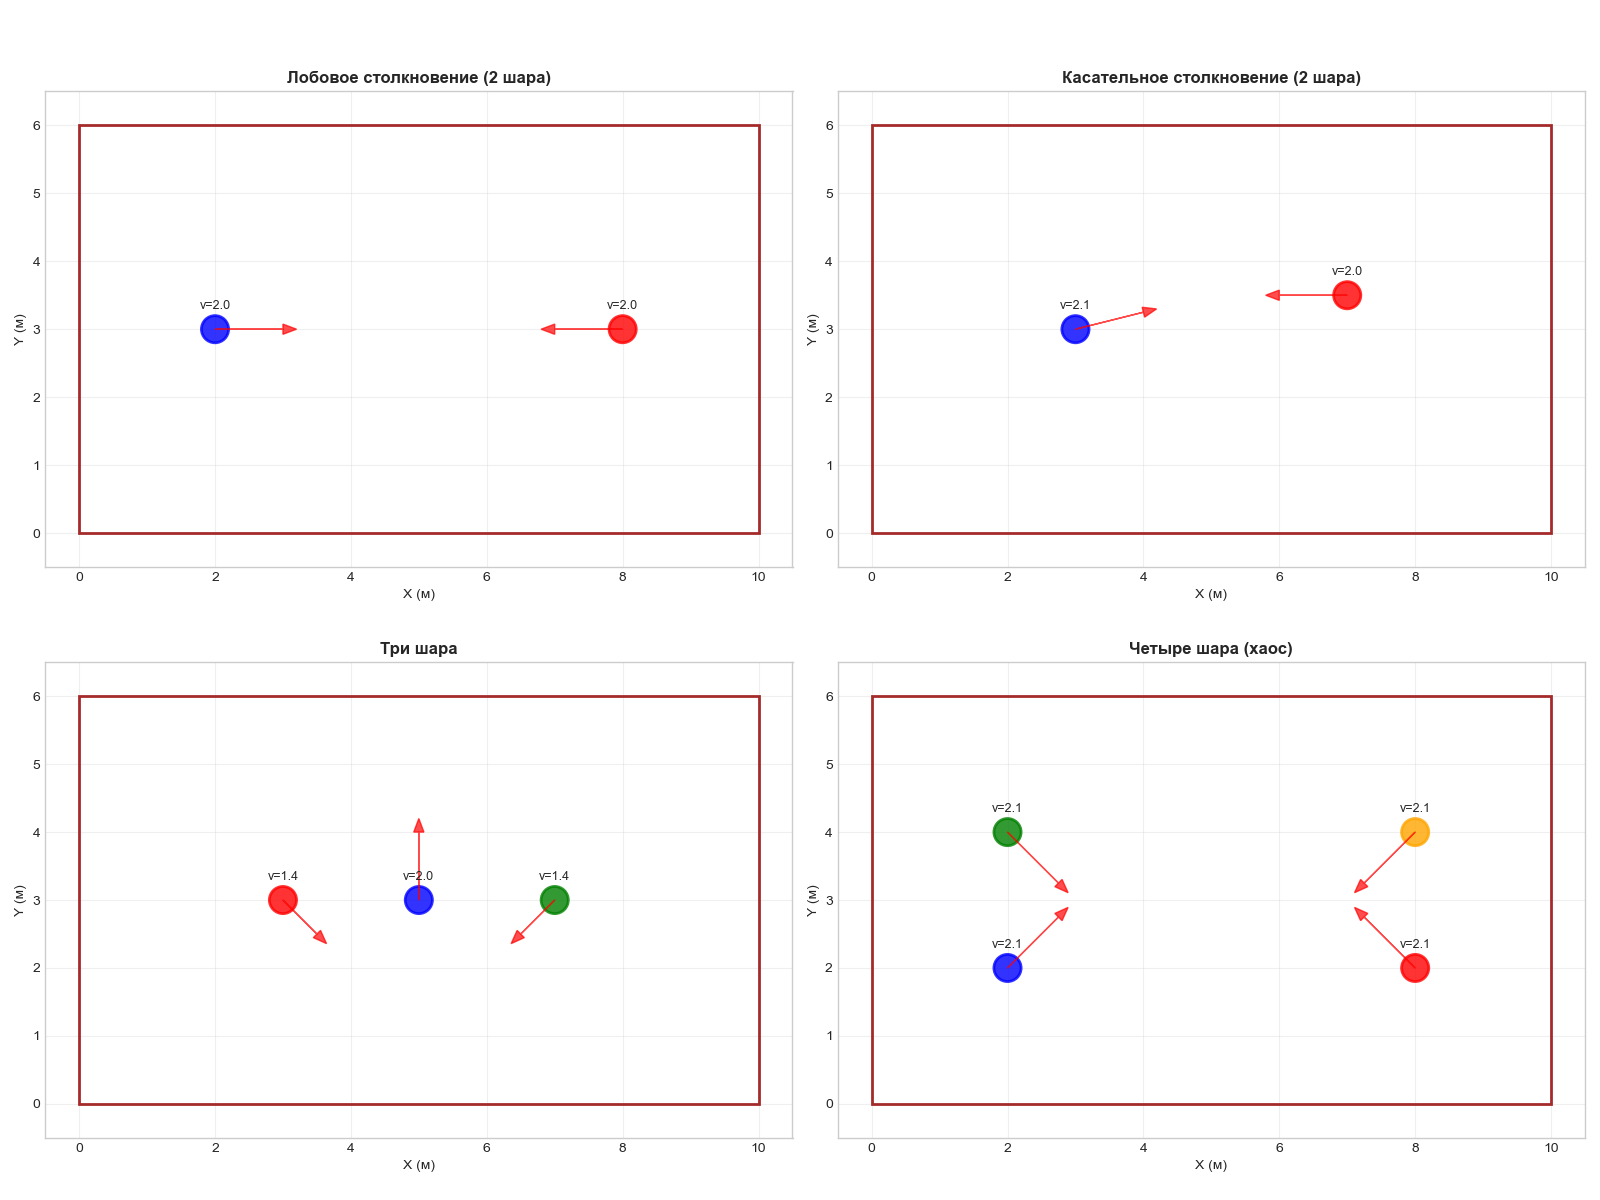

In [145]:

demonstrate_examples()

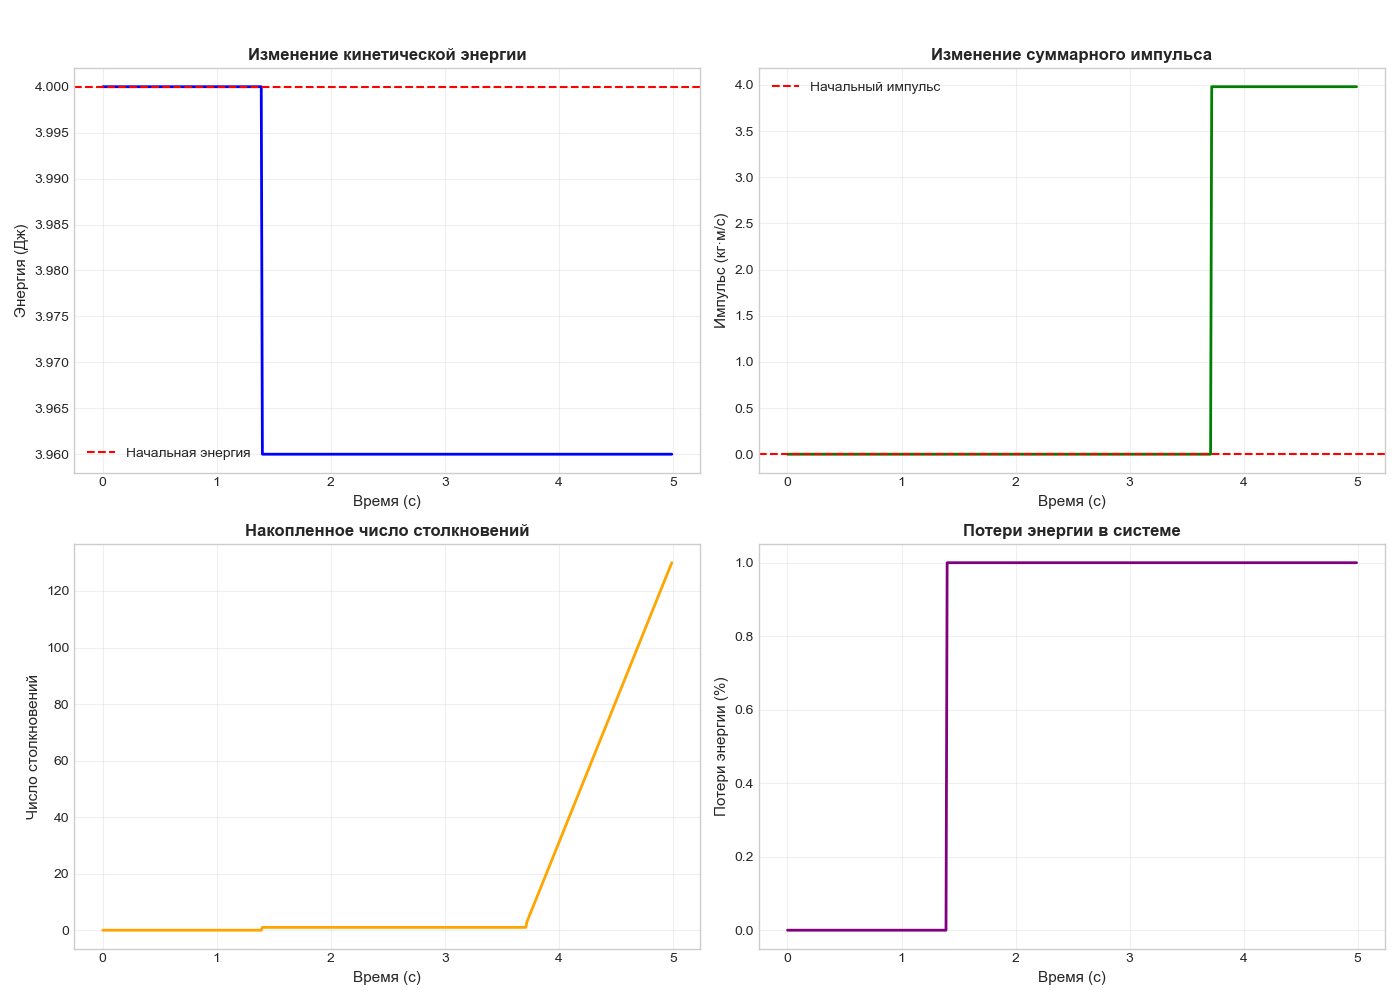

СТАТИСТИКА СИМУЛЯЦИИ
  Время симуляции: 5.00 с
 Число столкновений: 130
Начальная энергия: 4.0000 Дж
Конечная энергия: 3.9600 Дж
Потери энергии: 1.00%
 Начальный импульс: 0.0000 кг·м/с
 Конечный импульс: 3.9799 кг·м/с

 ВЫВОДЫ:
  ✓ Импульс сохраняется (разница: 3.979950 кг·м/с)
  ✓ Энергия уменьшается на 1.00% из-за потерь при столкновениях
  ✓ Каждое столкновение уменьшает энергию на ~1.0%


In [146]:
# Анализ законов сохранения
analyze_conservation()


# Ответы на контрольные вопросы

---

## 1. Законы сохранения импульса и энергии

### Закон сохранения импульса:
$$m_1\vec{v}_1 + m_2\vec{v}_2 = m_1\vec{v}_1' + m_2\vec{v}_2'$$

### Закон сохранения энергии (упругий удар):
$$\frac{1}{2}m_1v_1^2 + \frac{1}{2}m_2v_2^2 = \frac{1}{2}m_1v_1'^2 + \frac{1}{2}m_2v_2'^2$$

### С учётом потерь энергии (1%):
$$E' = E \cdot (1 - 0.01) = 0.99E$$

> **Импульс** сохраняется полностью, **энергия** — с потерями.

---

## 2. Как определить пересечение двух окружностей?

### Условие столкновения:
$$d = |\vec{r}_2 - \vec{r}_1| < R_1 + R_2$$

где:
- `d` — расстояние между центрами
- `R₁, R₂` — радиусы шаров

| Условие | Результат |
|---------|-----------|
| `d > R₁ + R₂` | Нет столкновения |
| `d = R₁ + R₂` | Касание |
| `d < R₁ + R₂` | Пересечение (столкновение) |

---

## 3. Нормаль столкновения

### Определение:
$$\vec{n} = \frac{\vec{r}_2 - \vec{r}_1}{|\vec{r}_2 - \vec{r}_1|}$$

Единичный вектор, направленный от центра первого шара ко второму.

### Почему важна нормаль?

При столкновении скорость разлагается на две составляющие:

| Составляющая | Направление | Что происходит |
|--------------|-------------|----------------|
| **Нормальная** `vₙ` | Вдоль нормали `n` | **Меняется** по закону удара |
| **Тангенциальная** `vₜ` | Перпендикулярно `n` | **Сохраняется** |

>  Без нормали невозможно правильно рассчитать обмен импульсом между шарами!

---

## 4. Коэффициент восстановления

### Определение:
$$e = \frac{|\vec{v}_2' - \vec{v}_1'|}{|\vec{v}_1 - \vec{v}_2|}$$

Отношение относительной скорости **после** удара к скорости **до** удара.

### Физический смысл:

| Значение `e` | Тип удара | Потери энергии |
|--------------|-----------|----------------|
| `e = 1` | Абсолютно упругий | 0% |
| `e = 0` | Абсолютно неупругий | 100% (шары слипаются) |
| `0 < e < 1` | Реальный удар | Частичные |

### В нашей модели:
$$e = \sqrt{1 - 0.01} = 0.995$$

---

## 5. Почему в реальном бильярде шар останавливается быстрее?

### Вывод:
> В реальной жизни шар останавливается за **5–10 секунд**, в нашей модели — может кататься **бесконечно** (только потери при ударах).

---
